## **IMPORTS**

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy torch scikit-learn matplotlib scipy tabulate tqdm

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from tabulate import tabulate

#get parent folder wrt the notebooks folder
PROJECT_ROOT = Path.cwd().parent 
sys.path.append(str(PROJECT_ROOT))
#Import metrics
from src.metrics import ema_advantage_per_drift, slope_initial_window, convergence_speed_per_drift


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## **RESULT SETS LOADING**

In [2]:
DATA_PATH = '../results'

clstm = np.load(f'{DATA_PATH}/cLSTM_results.npz')
cgru  = np.load(f'{DATA_PATH}/cGRU_results.npz')

## **METRIC FUNCTIONS**
The functions used in the training notebooks are imported from the py files, while these presented are new ones which will be useful to compare the models' results.

In [3]:
# Compute the first sample index where rolling kappa enters a stable region above the threshold.
# Defines "stable convergence" as kappa remaining at or above `threshold` for at least
# `stability_window` consecutive samples. Returns the index where that stable region begins,
# or None if no such region exists within the segment.
    
# This is a stricter notion of convergence than TTP (Time-To-Threshold), which only requires
# a single sample to cross the threshold. TTP can be triggered by transient spikes that the
# model immediately oscillates back down from. By contrast, time_to_stable_convergence only
# counts a recovery as successful if performance is sustained over a full window's worth of
# predictions, filtering out spurious crossings.
    
# Setting `stability_window` to the rolling kappa window size (e.g., 128) is a natural choice:
# it requires the model to maintain above-threshold performance for an entire kappa estimate's
# worth of consistent predictions, ensuring the apparent recovery is not a measurement artifact. 

#Returns: int or None — first sample index where stable convergence is achieved, or None if never.

def time_to_stable_convergence(segment, threshold, stability_window=128):
    """
    First sample index where kappa stays >= threshold for `stability_window` consecutive samples.
    Returns None if no such stable region exists in the segment.
    
    This is a stricter notion of convergence than TTP: it requires sustained performance
    rather than a single threshold crossing.
    """
    segment = np.array(segment)
    valid = np.isfinite(segment)
    above = valid & (segment >= threshold)
    
    # Sliding window check for `stability_window` consecutive Trues
    if len(above) < stability_window:
        return None
    
    for i in range(len(above) - stability_window + 1):
        if above[i:i + stability_window].all():
            return i
    return None

In [4]:
# Per-drift stable convergence analysis comparing online and EMA models.
# Mirrors the structure of convergence_speed_per_drift but uses the stricter
# time_to_stable_convergence metric in place of TTP. 
    
# Returns:
# list of dicts, one per drift, with TTSC values for both models and a boolean indicating
# whether EMA achieved stable convergence first (or rescued the case where online never
# achieved stable convergence at all).

def stable_convergence_per_drift(k_online, k_ema, tasks, ratio=0.9, stability_window=128):
    """
    Same structure as convergence_speed_per_drift but uses time_to_stable_convergence
    instead of first-threshold-crossing.
    """
    drift_points = [i for i in range(1, len(tasks)) if tasks[i] != tasks[i-1]]
    results = []
    
    for d in drift_points:
        next_drifts = [x for x in drift_points if x > d]
        concept_end = next_drifts[0] if next_drifts else len(k_online)
        
        seg_online = np.array(k_online[d:concept_end])
        seg_ema    = np.array(k_ema[d:concept_end])
        
        shared_max = max(np.nanmax(seg_online), np.nanmax(seg_ema))
        target = ratio * shared_max
        
        ttsc_online = time_to_stable_convergence(seg_online, target, stability_window)
        ttsc_ema    = time_to_stable_convergence(seg_ema,    target, stability_window)
        
        results.append({
            'drift_at': d,
            'concept_from': int(tasks[d - 1]),
            'concept_to':   int(tasks[d]),
            'ttsc_online': ttsc_online,
            'ttsc_ema':    ttsc_ema,
            'ttsc_ema_wins': (
                (ttsc_ema is not None and ttsc_online is not None and ttsc_ema < ttsc_online)
                or (ttsc_ema is not None and ttsc_online is None)
            ),
        })
    return results

## **UNIFIED RESULTS' DICTIONARY**

In [5]:
def load_results(npz, arch_name):
    """Build all_results-style dict from a loaded npz."""
    results = {}
    lambdas = [0.7, 0.8, 0.9, 0.95, 0.99]
    lambda_keys = ['L07', 'L08', 'L09', 'L095', 'L099']

    for lam, lkey in zip(lambdas, lambda_keys):
        for ds, ds_key in [('Weather', 'w'), ('AirQuality', 'aq')]:
            tasks = npz[f'tasks_{ds_key}']
            k_online = npz[f'k_{ds_key}_{lkey}_online']
            k_ema    = npz[f'k_{ds_key}_{lkey}_ema']

            conv = convergence_speed_per_drift(k_online, k_ema, tasks, SLOPE_WINDOW)
            adv  = ema_advantage_per_drift(k_online, k_ema, tasks, SLOPE_WINDOW)

            results[(arch_name, lam, ds)] = {
                'conv': conv, 'adv': adv,
                'k_online': k_online, 'k_ema': k_ema,
                'tasks': tasks
            }
    return results

SLOPE_WINDOW = int(clstm['SLOPE_WINDOW'])

all_results = {**load_results(clstm, 'cLSTM'),
                **load_results(cgru,  'cGRU')}

# **STATISTIC ANALYSIS**

## COMBINED SUMMARY TABLE

In [6]:
def build_summary_row(arch, lam, ds, conv, adv):
    ttp_pairs = [(r['ttp_online'], r['ttp_ema']) for r in conv
                  if r['ttp_online'] is not None and r['ttp_ema'] is not None]
    median_ttp_online = np.median([p[0] for p in ttp_pairs]) if ttp_pairs else np.nan
    median_ttp_ema    = np.median([p[1] for p in ttp_pairs]) if ttp_pairs else np.nan

    ttp_wins   = sum(r['ttp_ema_wins']   for r in conv)
    slope_wins = sum(r['slope_ema_wins'] for r in conv)
    adv_wins   = sum(r['ema_wins'] for r in adv)
    mean_gap   = np.nanmean([r['avg_gap'] for r in adv])

    return {
        'Arch': arch, 'λ': lam, 'Dataset': ds,
        'TTP wins':           f"{ttp_wins}/{len(conv)}",
        'Median TTP online':  f"{median_ttp_online:.0f}",
        'Median TTP EMA':     f"{median_ttp_ema:.0f}",
        'TTP delta (median)': f"{median_ttp_online - median_ttp_ema:+.0f}",
        'Slope wins':         f"{slope_wins}/{len(conv)}",
        'Adv wins':           f"{adv_wins}/{len(adv)}",
        'Mean kappa gap':     f"{mean_gap:+.4f}",
    }

rows = [build_summary_row(arch, lam, ds, data['conv'], data['adv'])
         for (arch, lam, ds), data in all_results.items()]

df = pd.DataFrame(rows)

# Sort by λ then Dataset then Architecture for readability
df = df.sort_values(['λ', 'Dataset', 'Arch']).reset_index(drop=True)

# Add separators between architecture+lambda groups
new_rows = []
prev_key = None
for _, row in df.iterrows():
    key = (row['λ'])
    if prev_key is not None and key != prev_key:
        new_rows.append({col: '' for col in df.columns})
    new_rows.append(row.to_dict())
    prev_key = key
df_separated = pd.DataFrame(new_rows)

n_cols = len(df_separated.columns)
print(tabulate(df_separated, headers='keys', tablefmt='grid', showindex=False,
                colalign=('left',) * 3 + ('center',) * (n_cols - 3)))

+--------+------+------------+------------+---------------------+------------------+----------------------+--------------+------------+------------------+
| Arch   | λ    | Dataset    |  TTP wins  |  Median TTP online  |  Median TTP EMA  |  TTP delta (median)  |  Slope wins  |  Adv wins  |  Mean kappa gap  |
+========+======+============+============+=====================+==================+======================+==============+============+==================+
| cGRU   | 0.7  | AirQuality |    1/7     |        19505        |      23033       |        -3528         |     2/7      |    2/7     |     -0.0025      |
+--------+------+------------+------------+---------------------+------------------+----------------------+--------------+------------+------------------+
| cLSTM  | 0.7  | AirQuality |    2/7     |        4282         |       8031       |        -3749         |     0/7      |    0/7     |     -0.0071      |
+--------+------+------------+------------+---------------------+-----

## TTP DELTA BAR CHART BY DATASET

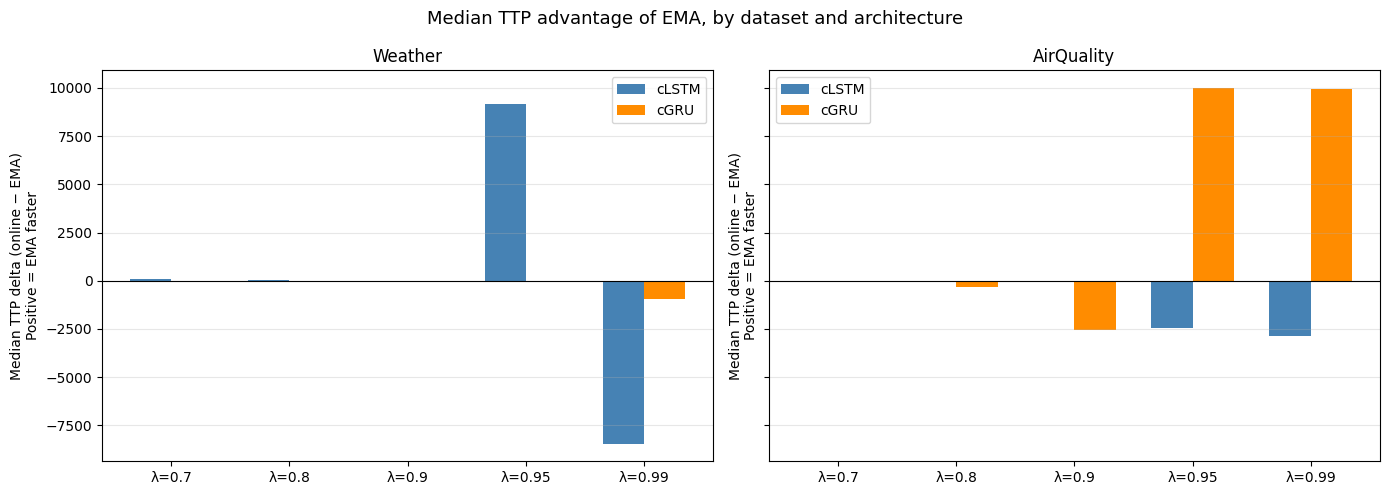

In [7]:
def collect_ttp_deltas(all_results):
    """Returns a list of records with all per-drift TTP deltas."""
    records = []
    for (arch, lam, ds), data in all_results.items():
        for r in data['conv']:
            if r['ttp_online'] is not None and r['ttp_ema'] is not None:
                records.append({
                    'Arch': arch, 'λ': lam, 'Dataset': ds,
                    'transition': f"C{r['concept_from']}→C{r['concept_to']}",
                    'delta': r['ttp_online'] - r['ttp_ema']  # +ve = EMA faster
                })
    return pd.DataFrame(records)

deltas_df = collect_ttp_deltas(all_results)

# Plot: TTP delta grouped by dataset, with bars per (arch, lambda)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, ds in zip(axes, ['Weather', 'AirQuality']):
    sub = deltas_df[deltas_df['Dataset'] == ds]
    # Aggregate: median TTP delta per (arch, lambda)
    agg = sub.groupby(['Arch', 'λ'])['delta'].median().unstack('Arch')

    x = np.arange(len(agg.index))
    width = 0.35
    ax.bar(x - width/2, agg['cLSTM'], width, label='cLSTM', color='steelblue')
    ax.bar(x + width/2, agg['cGRU'],  width, label='cGRU',  color='darkorange')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'λ={l}' for l in agg.index])
    ax.set_title(f'{ds}')
    ax.set_ylabel('Median TTP delta (online − EMA)\nPositive = EMA faster')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Median TTP advantage of EMA, by dataset and architecture', fontsize=13)
plt.tight_layout()
plt.show()

## **TTP vs TTSC: Real convergence analysis**
For each concept drift, we analyse the TTSC (Time-To-Stable-Convergence): the first sample where rolling kappa stays at orabove `ratio` × shared_max for at least `stability_window` consecutive samples.
Both models are evaluated against the same target (the higher of their two within-concept maximum kappa values, scaled by `ratio`) for fair comparison.
    
It is used as a complementary metric to TTP: TTP measures first attainment of recovery (which can be a transient spike), while TTSC measures genuine convergence to a stable predictive regime. The gap between TTP wins and TTSC wins reveals how much of EMA's apparent convergence advantage corresponds to sustained recovery vs. brief threshold crossings.

In [8]:
# Compute stable convergence for all experiments
stable_results = {}
for (arch, lam, ds), data in all_results.items():
    stable_results[(arch, lam, ds)] = stable_convergence_per_drift(
        data['k_online'], data['k_ema'], data['tasks'],
        ratio=0.9, stability_window=128
    )

# Build a comparison table: TTP vs TTSC
rows = []
for (arch, lam, ds), conv in stable_results.items():
    base_conv = all_results[(arch, lam, ds)]['conv']
    
    ttp_pairs = [(r['ttp_online'], r['ttp_ema']) for r in base_conv
                  if r['ttp_online'] is not None and r['ttp_ema'] is not None]
    ttsc_pairs = [(r['ttsc_online'], r['ttsc_ema']) for r in conv
                   if r['ttsc_online'] is not None and r['ttsc_ema'] is not None]
    
    if ttp_pairs:
        med_online = np.median([p[0] for p in ttp_pairs])
        med_ema    = np.median([p[1] for p in ttp_pairs])
        ttp_med_delta = med_online - med_ema
    else:
        ttp_med_delta = np.nan
    if ttsc_pairs:
        med_online = np.median([p[0] for p in ttsc_pairs])
        med_ema    = np.median([p[1] for p in ttsc_pairs])
        ttsc_med_delta = med_online - med_ema
    else:
        ttsc_med_delta = np.nan
    
    n_stable_online = sum(1 for r in conv if r['ttsc_online'] is not None)
    n_stable_ema    = sum(1 for r in conv if r['ttsc_ema']    is not None)
    
    rows.append({
        'Arch': arch, 'λ': lam, 'Dataset': ds,
        'TTP delta (median)':  f"{ttp_med_delta:+.0f}"  if not np.isnan(ttp_med_delta)  else 'N/A',
        'TTSC delta (median)': f"{ttsc_med_delta:+.0f}" if not np.isnan(ttsc_med_delta) else 'N/A',
        'Online stable on':    f"{n_stable_online}/7 drifts",
        'EMA stable on':       f"{n_stable_ema}/7 drifts",
    })

df_stable = pd.DataFrame(rows).sort_values(['λ', 'Dataset', 'Arch']).reset_index(drop=True)

# Add separators between λ groups
new_rows = []
prev_lambda = None
for _, row in df_stable.iterrows():
    if prev_lambda is not None and row['λ'] != prev_lambda:
        new_rows.append({col: '' for col in df_stable.columns})
    new_rows.append(row.to_dict())
    prev_lambda = row['λ']
df_stable_sep = pd.DataFrame(new_rows)

print("Comparison: TTP (first crossing) vs TTSC (stable convergence)")
print("Negative delta = online faster | Positive delta = EMA faster | N/A = neither model achieved stable convergence\n")
print(tabulate(df_stable_sep, headers='keys', tablefmt='grid', showindex=False,
                colalign=('left',)*3 + ('center',)*4))

Comparison: TTP (first crossing) vs TTSC (stable convergence)
Negative delta = online faster | Positive delta = EMA faster | N/A = neither model achieved stable convergence

+--------+------+------------+----------------------+-----------------------+--------------------+-----------------+
| Arch   | λ    | Dataset    |  TTP delta (median)  |  TTSC delta (median)  |  Online stable on  |  EMA stable on  |
+========+======+============+======================+=======================+====================+=================+
| cGRU   | 0.7  | AirQuality |        -3528         |          N/A          |     0/7 drifts     |   0/7 drifts    |
+--------+------+------------+----------------------+-----------------------+--------------------+-----------------+
| cLSTM  | 0.7  | AirQuality |        -3749         |          +0           |     1/7 drifts     |   1/7 drifts    |
+--------+------+------------+----------------------+-----------------------+--------------------+-----------------+
| cGRU 

In [9]:
for (arch, lam, ds), data in all_results.items():
    conv = data['conv']
    mean_slope_online = np.nanmean([r['slope_online'] for r in conv])
    mean_slope_ema    = np.nanmean([r['slope_ema']    for r in conv])
    slope_delta = mean_slope_ema - mean_slope_online
    print(f"{arch} | λ={lam} | {ds}: slope delta = {slope_delta:+.5f}")

cLSTM | λ=0.7 | Weather: slope delta = -0.00004
cLSTM | λ=0.7 | AirQuality: slope delta = -0.00003
cLSTM | λ=0.8 | Weather: slope delta = -0.00009
cLSTM | λ=0.8 | AirQuality: slope delta = -0.00005
cLSTM | λ=0.9 | Weather: slope delta = -0.00010
cLSTM | λ=0.9 | AirQuality: slope delta = -0.00000
cLSTM | λ=0.95 | Weather: slope delta = -0.00012
cLSTM | λ=0.95 | AirQuality: slope delta = +0.00001
cLSTM | λ=0.99 | Weather: slope delta = -0.00014
cLSTM | λ=0.99 | AirQuality: slope delta = +0.00001
cGRU | λ=0.7 | Weather: slope delta = +0.00005
cGRU | λ=0.7 | AirQuality: slope delta = -0.00002
cGRU | λ=0.8 | Weather: slope delta = +0.00010
cGRU | λ=0.8 | AirQuality: slope delta = -0.00003
cGRU | λ=0.9 | Weather: slope delta = +0.00007
cGRU | λ=0.9 | AirQuality: slope delta = -0.00005
cGRU | λ=0.95 | Weather: slope delta = -0.00004
cGRU | λ=0.95 | AirQuality: slope delta = -0.00003
cGRU | λ=0.99 | Weather: slope delta = -0.00003
cGRU | λ=0.99 | AirQuality: slope delta = +0.00018


### **VISUALIZATION - COMPARISON BAR CHART**

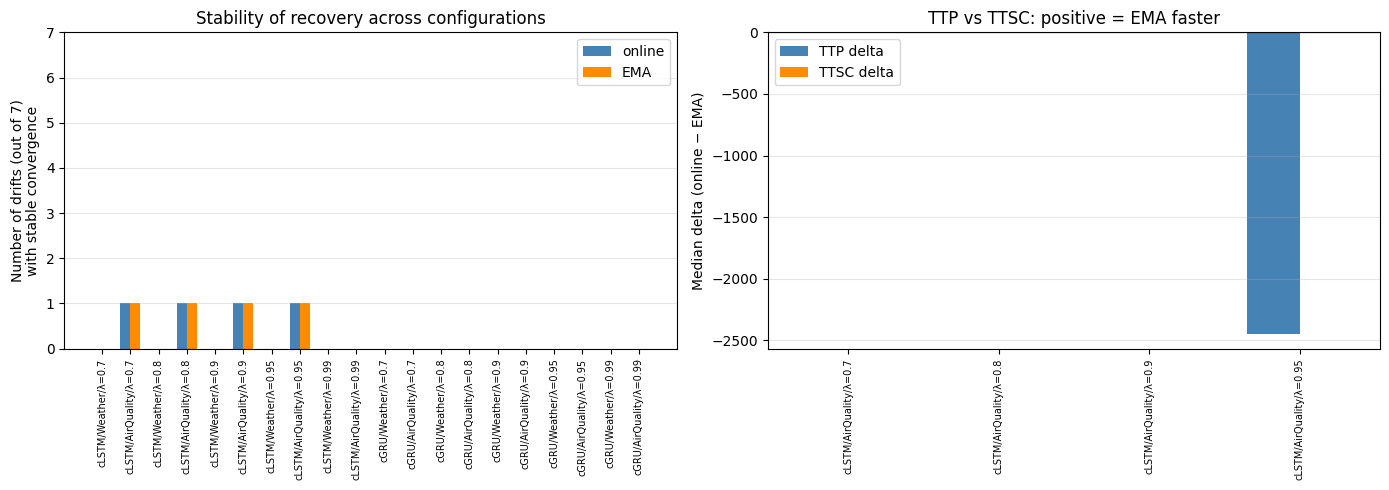

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: how often each model achieves stable convergence
stable_counts = []
for (arch, lam, ds), conv in stable_results.items():
    n_stable_online = sum(1 for r in conv if r['ttsc_online'] is not None)
    n_stable_ema    = sum(1 for r in conv if r['ttsc_ema']    is not None)
    stable_counts.append({
        'config': f"{arch}/{ds}/λ={lam}",
        'online': n_stable_online,
        'ema': n_stable_ema
    })

stable_df = pd.DataFrame(stable_counts)
x = np.arange(len(stable_df))
width = 0.35

axes[0].bar(x - width/2, stable_df['online'], width, label='online', color='steelblue')
axes[0].bar(x + width/2, stable_df['ema'],    width, label='EMA',    color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(stable_df['config'], rotation=90, fontsize=7)
axes[0].set_ylabel('Number of drifts (out of 7)\nwith stable convergence')
axes[0].set_title('Stability of recovery across configurations')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 7)

# Right: median delta comparison TTP vs TTSC
ttp_deltas, ttsc_deltas, labels = [], [], []
for (arch, lam, ds), conv in stable_results.items():
    base_conv = all_results[(arch, lam, ds)]['conv']
    ttp_pairs  = [(r['ttp_online'],  r['ttp_ema'])  for r in base_conv
                   if r['ttp_online']  is not None and r['ttp_ema']  is not None]
    ttsc_pairs = [(r['ttsc_online'], r['ttsc_ema']) for r in conv
                   if r['ttsc_online'] is not None and r['ttsc_ema'] is not None]
    if ttp_pairs and ttsc_pairs:
        ttp_deltas.append(np.median([p[0]-p[1] for p in ttp_pairs]))
        ttsc_deltas.append(np.median([p[0]-p[1] for p in ttsc_pairs]))
        labels.append(f"{arch}/{ds}/λ={lam}")

x = np.arange(len(labels))
axes[1].bar(x - width/2, ttp_deltas,  width, label='TTP delta',  color='steelblue')
axes[1].bar(x + width/2, ttsc_deltas, width, label='TTSC delta', color='darkorange')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=90, fontsize=7)
axes[1].set_ylabel('Median delta (online − EMA)')
axes[1].set_title('TTP vs TTSC: positive = EMA faster')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## FINAL ANSWER: DISTRIBUTION OF ALL TTP DELTAS

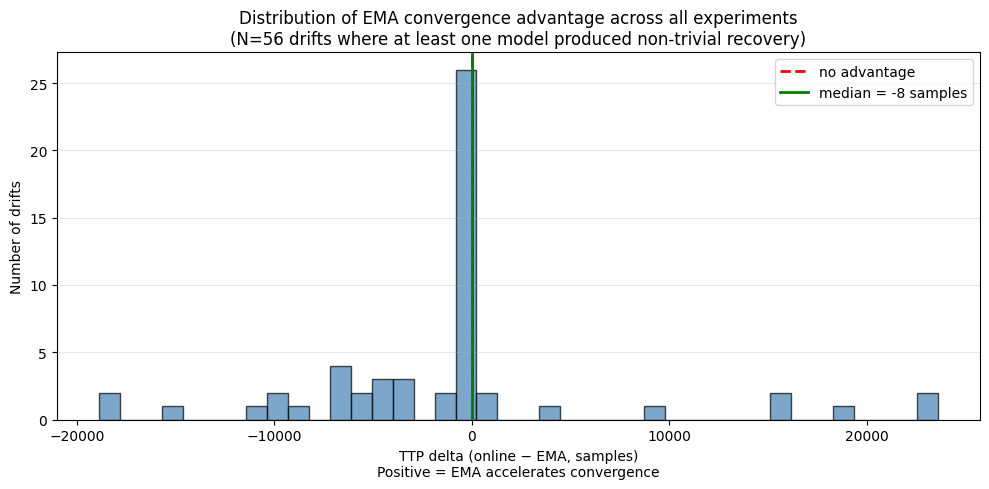


Across all 56 non-trivial drifts:
  EMA faster:     21 (37.5%)
  Online faster:  35 (62.5%)
  Tied:            0 (0.0%)
  Median delta:  -8 samples
  Mean delta:    -761 samples


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

# Filter to drifts where there's actual signal (not flat-zero degenerate)
valid_deltas = deltas_df[deltas_df['delta'].abs() > 0]['delta'].values

ax.hist(valid_deltas, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', label='no advantage', linewidth=2)
ax.axvline(np.median(valid_deltas), color='green', linestyle='-',
            label=f'median = {np.median(valid_deltas):+.0f} samples', linewidth=2)

ax.set_xlabel('TTP delta (online − EMA, samples)\nPositive = EMA accelerates convergence')
ax.set_ylabel('Number of drifts')
ax.set_title(f'Distribution of EMA convergence advantage across all experiments\n'
              f'(N={len(valid_deltas)} drifts where at least one model produced non-trivial recovery)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Companion summary
n_total = len(valid_deltas)
n_ema_faster = (valid_deltas > 0).sum()
n_online_faster = (valid_deltas < 0).sum()
n_tied = (valid_deltas == 0).sum()

print(f"\nAcross all {n_total} non-trivial drifts:")
print(f"  EMA faster:    {n_ema_faster:3d} ({100*n_ema_faster/n_total:.1f}%)")
print(f"  Online faster: {n_online_faster:3d} ({100*n_online_faster/n_total:.1f}%)")
print(f"  Tied:          {n_tied:3d} ({100*n_tied/n_total:.1f}%)")
print(f"  Median delta:  {np.median(valid_deltas):+.0f} samples")
print(f"  Mean delta:    {np.mean(valid_deltas):+.0f} samples")

## PER-DRIFT ΔTTP DISTRIBUTION

This plot shows the distribution of TTP deltas across all non-trivial drift transitions.

The linear scale highlights that most drifts are close to zero, while the symlog scale makes the extreme positive and negative tails visible.
Positive ΔTTP means EMA reaches the threshold earlier; negative ΔTTP means the online model reaches it earlier.

The goal is not to claim stable convergence, but to show that EMA strongly reshapes transient threshold-crossing behaviour in a transition-dependent way.

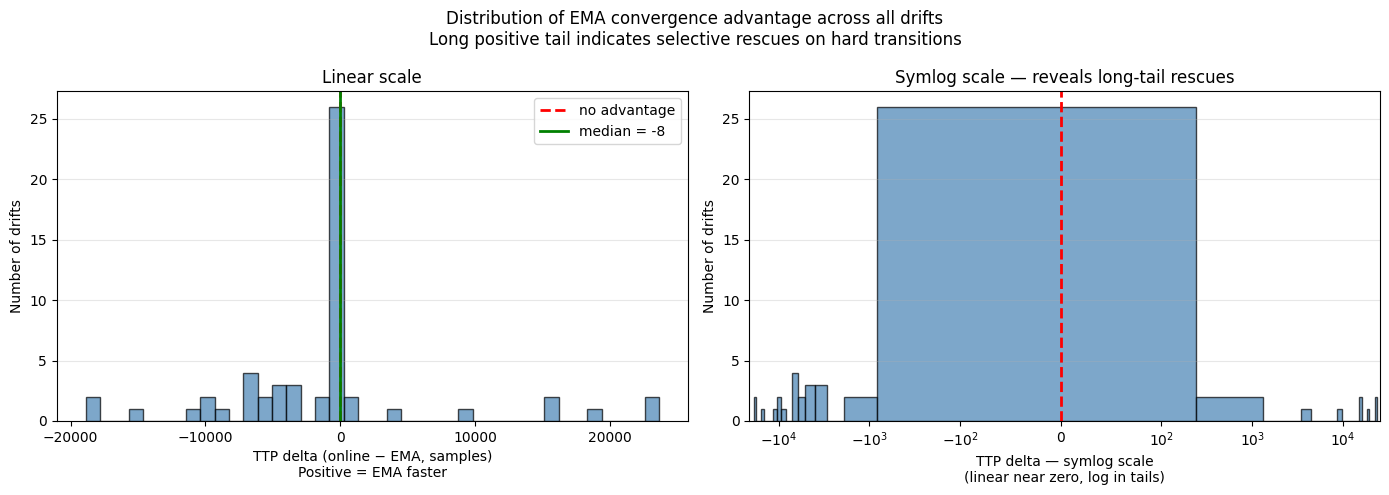


Top 8 EMA wins (largest positive TTP delta):
 Arch    λ    Dataset transition  delta
 cGRU 0.95 AirQuality      C5→C6  23622
 cGRU 0.99 AirQuality      C5→C6  23616
 cGRU 0.99    Weather      C2→C3  18471
 cGRU 0.95    Weather      C1→C2  15802
cLSTM 0.95    Weather      C5→C6  15708
cLSTM 0.95    Weather      C4→C5   9171
 cGRU 0.90    Weather      C1→C2   3970
cLSTM 0.90    Weather      C3→C4   1091

Top 8 Online wins (largest negative TTP delta):
 Arch    λ    Dataset transition  delta
 cGRU 0.70 AirQuality      C4→C5 -18886
 cGRU 0.80 AirQuality      C4→C5 -18886
cLSTM 0.70 AirQuality      C7→C8 -14656
cLSTM 0.80 AirQuality      C6→C7 -10424
 cGRU 0.95    Weather      C6→C7  -9696
 cGRU 0.99    Weather      C6→C7  -9696
cLSTM 0.99    Weather      C6→C7  -8440
 cGRU 0.80    Weather      C4→C5  -6636


In [ ]:
# Per-drift TTP delta histogram 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: linear scale, full range ---
ax = axes[0]
ax.hist(valid_deltas, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='no advantage')
ax.axvline(np.median(valid_deltas), color='green', linestyle='-', linewidth=2,
            label=f'median = {np.median(valid_deltas):+.0f}')
ax.set_xlabel('TTP delta (online − EMA, samples)\nPositive = EMA faster')
ax.set_ylabel('Number of drifts')
ax.set_title('Linear scale')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# --- Right panel: symlog scale, reveals long-tail rescues ---
ax = axes[1]
ax.hist(valid_deltas, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xscale('symlog', linthresh=100)  # linear in [-100, 100], log outside
ax.set_xlabel('TTP delta — symlog scale\n(linear near zero, log in tails)')
ax.set_ylabel('Number of drifts')
ax.set_title('Symlog scale — reveals long-tail rescues')
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribution of EMA convergence advantage across all drifts\n'
              'Long positive tail indicates selective rescues on hard transitions',
              fontsize=12)
plt.tight_layout()
plt.show()

# --- Companion table: extreme deltas (top rescues both directions) ---
top_n = 8
top_ema = deltas_df.nlargest(top_n, 'delta')[['Arch', 'λ', 'Dataset', 'transition', 'delta']]
top_online = deltas_df.nsmallest(top_n, 'delta')[['Arch', 'λ', 'Dataset', 'transition', 'delta']]

print(f"\nTop {top_n} EMA wins (largest positive TTP delta):")
print(top_ema.to_string(index=False))

print(f"\nTop {top_n} Online wins (largest negative TTP delta):")
print(top_online.to_string(index=False))